<a href="https://colab.research.google.com/github/manojgautamx/DeepLearningWorkshops/blob/main/6CS012_Workshop5_Manoj_Gautam_2409334.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

In [ ]:
!unzip /content/FruitinAmazon.zip -d /content/

Archive:  /content/FruitinAmazon.zip
  inflating: /content/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/FruitinAmazon/test/pupunha/download (4).jpeg  
  inflating: /content/FruitinAmazon/train/acai/images (11).jpeg  
  inflating: /co

**Task 1 — Data Understanding & Visualization**

Part 1: Visualise one image per class

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import random

# --- UPDATE THESE PATHS to match your Google Drive ---
train_dir = "/content/FruitinAmazon/train"
test_dir  = "/content/FruitinAmazon/test"

img_height   = 128
img_width    = 128
batch_size   = 32
num_classes  = 6        # pupunha, guarana, graviola, tucuma, acai, cupuacu

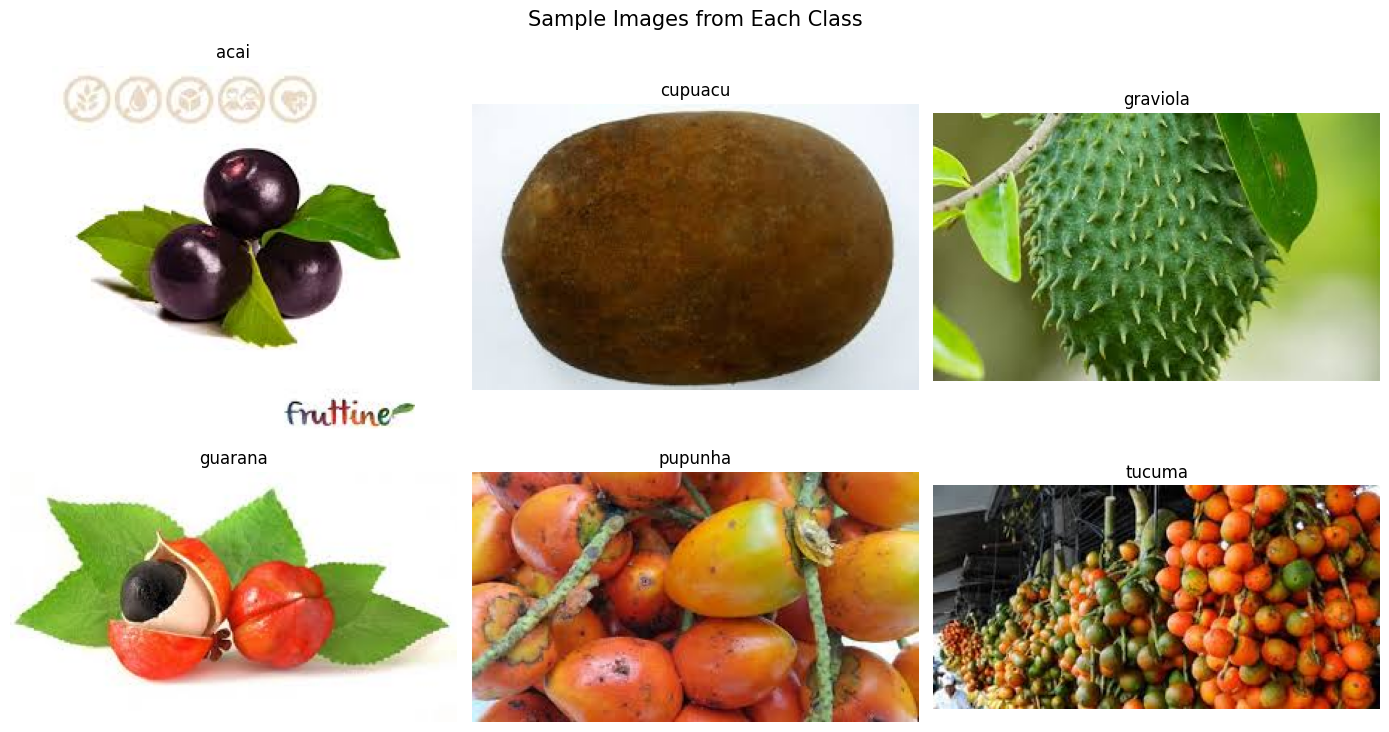

In [ ]:
class_dirs = sorted(os.listdir(train_dir))  # ['acai', 'cupuacu', ...]
num_classes = len(class_dirs)

cols = 3
rows = (num_classes + cols - 1) // cols     # enough rows to fit all classes

plt.figure(figsize=(14, rows * 4))
for idx, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    img_file = random.choice(images)
    img = Image.open(os.path.join(class_path, img_file)).convert("RGB")

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=12)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=15)
plt.tight_layout()
plt.show()

Part 2: Check for and remove corrupted images

In [ ]:
corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        img_path = os.path.join(class_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()                    # catches most corruption
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No corrupted images found.")

No corrupted images found.


**Task 2 — Load & Preprocess with Keras**

In [ ]:
# --- Training dataset ---
train_ds = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123,
)

# ✅ Save class names RIGHT HERE, before any transformations
class_names = train_ds.class_names
print("Class names:", class_names)
num_classes = len(class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# --- Validation dataset ---
val_ds = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123,
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# --- Test dataset ---
test_ds = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


**Task 3 — Build the CNN**

In [ ]:
model = Sequential([
    # --- Convolutional Block 1 ---
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # --- Convolutional Block 2 ---
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    # --- Fully Connected Head ---
    layers.Flatten(),
    layers.Dense(64,  activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),   # one node per class
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4 — Compile & Train**

Compile:

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # labels are integers
    metrics=["accuracy"],
)

Set up callbacks:

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

model_checkpoint = ModelCheckpoint(
    filepath="best_fruit_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

Train:

In [ ]:
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,           # worksheet specifies batch_size=16 here
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.1904 - loss: 1.8847
Epoch 1: val_loss improved from None to 1.70478, saving model to best_fruit_model.keras

Epoch 1: finished saving model to best_fruit_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.1806 - loss: 1.9260 - val_accuracy: 0.1667 - val_loss: 1.7048
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3947 - loss: 1.6685
Epoch 2: val_loss improved from 1.70478 to 1.46626, saving model to best_fruit_model.keras

Epoch 2: finished saving model to best_fruit_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.4028 - loss: 1.6425 - val_accuracy: 0.7778 - val_loss: 1.4663
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.4606 - loss: 1.4838
Epoch 3: val_loss improved from 1.46626 to 1.15492, saving model to best_fruit_model.keras

Epoch 3: finished saving model to best_fruit_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.4444 - loss: 1.440

Plot training curves:

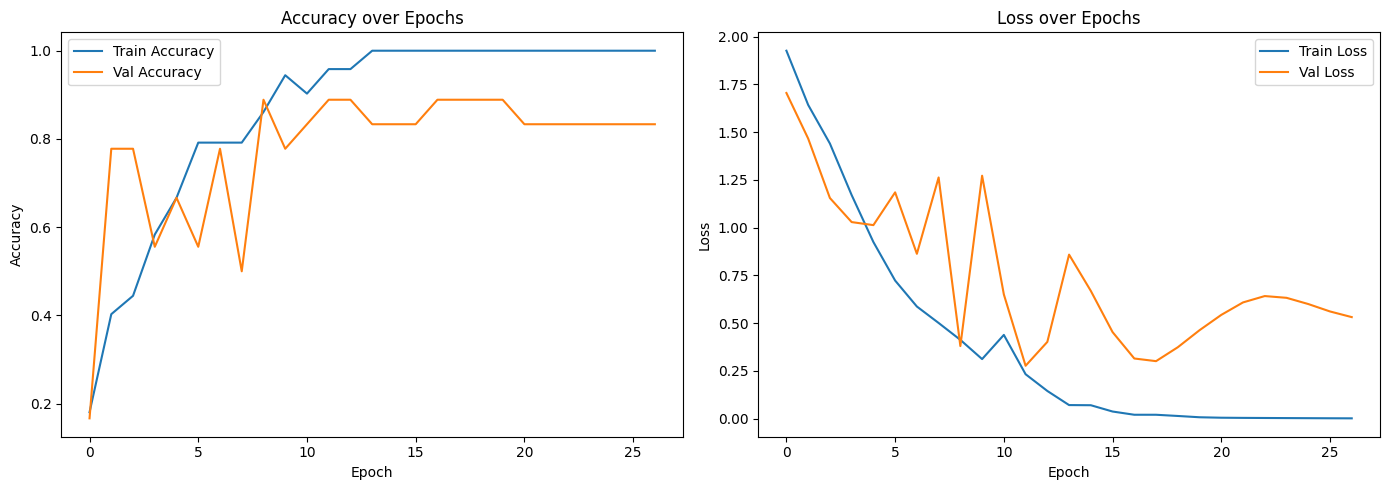

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

**Task 5 — Evaluate the Model**

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6333 - loss: 0.8543

Test Loss    : 0.8543
Test Accuracy: 0.6333


**Task 6 — Save & Reload**

In [ ]:
# Save
model.save("fruit_cnn_model.h5")
print("Model saved.")

# Load
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")

# Re-evaluate to confirm it works
loss, acc = loaded_model.evaluate(test_ds)
print(f"Reloaded model — Test Accuracy: {acc:.4f}")

Model saved.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6333 - loss: 0.8543
Reloaded model — Test Accuracy: 0.6333


**Task 7 — Predictions & Classification Report**

In [ ]:
# Collect all true labels and predictions from test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.40      0.40      0.40         5
    graviola       0.67      0.80      0.73         5
     guarana       1.00      0.60      0.75         5
     pupunha       1.00      1.00      1.00         5
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.63        30
   macro avg       0.68      0.63      0.65        30
weighted avg       0.68      0.63      0.65        30



Visualise some predictions:

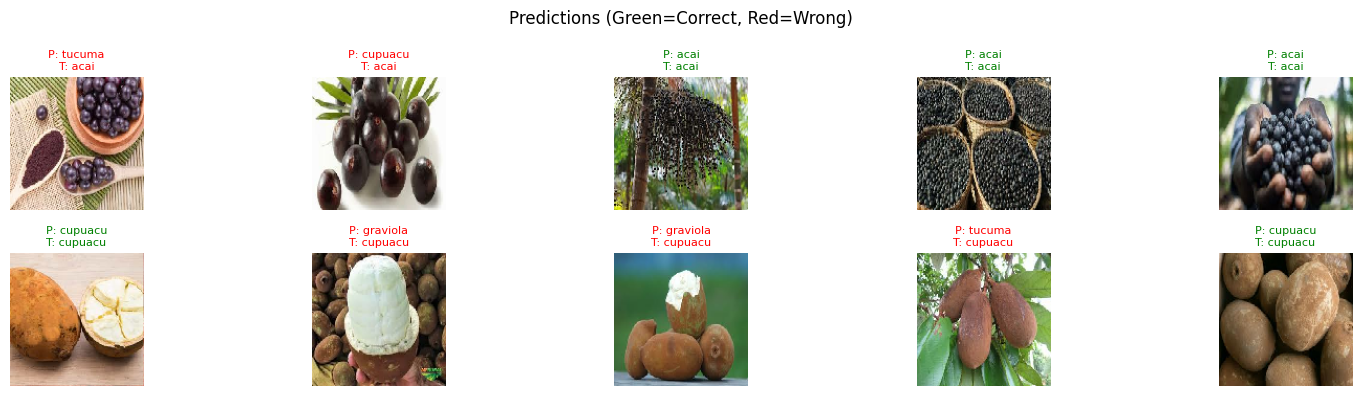

In [ ]:
sample_images, sample_labels = next(iter(test_ds))
preds = loaded_model.predict(sample_images[:10], verbose=0)
pred_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(16, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].numpy())
    true_name = class_names[sample_labels[i]]
    pred_name = class_names[pred_labels[i]]
    color = "green" if pred_labels[i] == sample_labels[i] else "red"
    plt.title(f"P: {pred_name}\nT: {true_name}", color=color, fontsize=8)
    plt.axis("off")
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()